# CSE 429 — Final Project: Real vs. AI-Generated Image Detection

## Abstract
We implement a lite version of **"CNN-generated images are surprisingly easy to spot... for now"** (Wang et al., 2020). The paper shows that a ResNet-50 classifier trained with careful Gaussian blur and JPEG compression augmentation generalises surprisingly well across unseen CNN generators. We adapt this approach to our dataset of 20 PASCAL VOC categories, each containing real photographs and AI-generated counterparts, and evaluate using Average Precision (AP) — the paper's primary metric.

---

## Cell 1 — Setup & Imports

In [16]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageFilter
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Safe CUDA check — falls back to CPU if GPU kernel is incompatible ─────────
try:
    _test = torch.zeros(1).cuda()
    _ = _test + 1
    DEVICE = torch.device('cuda')
    print(f'Using device: CUDA ({torch.cuda.get_device_name(0)})')
except Exception as e:
    print(f'CUDA unavailable ({e.__class__.__name__}), falling back to CPU')
    DEVICE = torch.device('cpu')

Using device: CUDA (Tesla T4)


## Cell 2 — Dataset Configuration

In [17]:
# ── Update this path to match your Kaggle input ───────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/marawanmogeb/cv-project-dataset-mini/dataset_split')

CLASSES = [
    'airplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

LABEL_MAP  = {'0_real': 0, '1_fake': 1}
LABEL_NAME = {0: 'Real', 1: 'Fake'}
SPLITS     = ['train', 'val', 'test']

# ── Hyper-parameters (paper defaults) ────────────────────────────────────────
IMG_SIZE   = 224       # paper: 224×224 crop, no resize
BATCH_SIZE = 32
EPOCHS     = 15
LR         = 1e-4      # paper uses Adam lr=1e-4

# ── Wang et al. augmentation probabilities ────────────────────────────────────
BLUR_PROB  = 0.5       # Gaussian blur applied with 50% probability
JPEG_PROB  = 0.5       # JPEG compression applied with 50% probability

MODEL_NAME = 'ResNet50-Wang2020'

print(f'Dataset root exists: {DATASET_ROOT.exists()}')
print(f'Model: {MODEL_NAME}')
print(f'Blur prob: {BLUR_PROB} | JPEG prob: {JPEG_PROB}')

Dataset root exists: True
Model: ResNet50-Wang2020
Blur prob: 0.5 | JPEG prob: 0.5


## Cell 3 — Exploratory Data Analysis

Records collected: 120

=== Total image counts per split ===
label   Fake   Real
split              
test    5975   6025
train  27909  28091
val     6116   5884


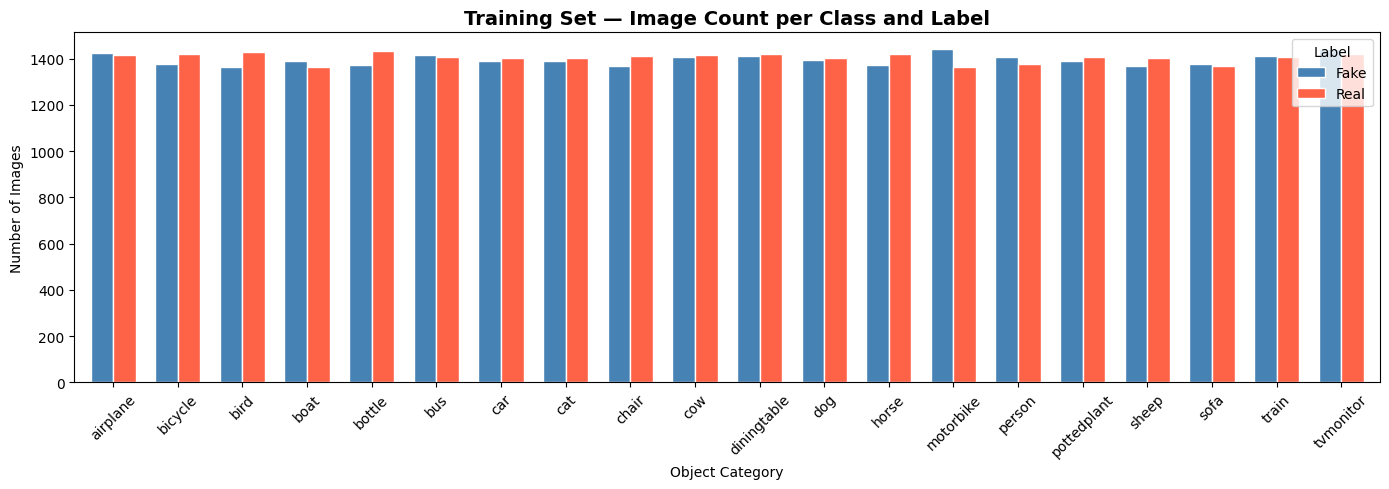

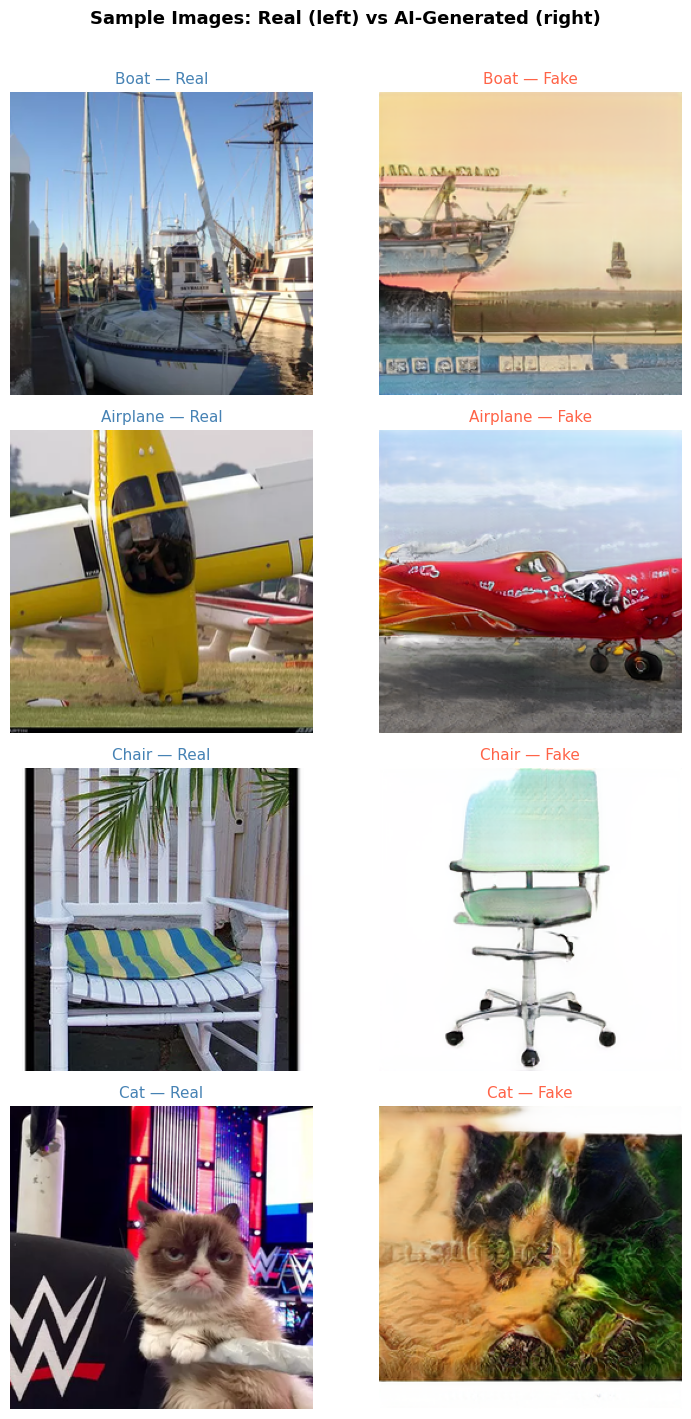

In [18]:
records = []
for split in SPLITS:
    split_path = DATASET_ROOT / split
    if not split_path.exists():
        print(f'[WARN] Split folder not found: {split_path}')
        continue
    for cls_folder in sorted(split_path.iterdir()):
        if not cls_folder.is_dir():
            continue
        cls = cls_folder.name
        for lbl_folder in sorted(cls_folder.iterdir()):
            if not lbl_folder.is_dir():
                continue
            lbl_dir = lbl_folder.name
            lbl_id  = LABEL_MAP.get(lbl_dir)
            if lbl_id is None:
                continue
            imgs = [f for f in lbl_folder.iterdir()
                    if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}]
            records.append({
                'split': split, 'class': cls,
                'label': LABEL_NAME[lbl_id], 'count': len(imgs)
            })

print(f'Records collected: {len(records)}')

if not records:
    print('[ERROR] No records found. Subfolders at DATASET_ROOT:')
    if DATASET_ROOT.exists():
        for p in DATASET_ROOT.iterdir(): print(' ', p)
else:
    df = pd.DataFrame(records)
    print('\n=== Total image counts per split ===')
    print(df.groupby(['split', 'label'])['count'].sum().unstack())

    # Per-class bar chart
    train_df = df[df['split'] == 'train'].copy()
    pivot    = train_df.pivot(index='class', columns='label', values='count').fillna(0)

    fig, ax = plt.subplots(figsize=(14, 5))
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
               edgecolor='white', width=0.7)
    ax.set_title('Training Set — Image Count per Class and Label',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Object Category')
    ax.set_ylabel('Number of Images')
    ax.legend(title='Label')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Sample images
    sample_classes = random.sample(CLASSES, min(4, len(CLASSES)))
    fig, axes = plt.subplots(4, 2, figsize=(8, 14))
    for row, cls in enumerate(sample_classes):
        for col, (lbl_dir, lbl_id) in enumerate(LABEL_MAP.items()):
            folder = DATASET_ROOT / 'train' / cls / lbl_dir
            imgs   = list(folder.glob('*.*')) if folder.exists() else []
            if imgs:
                img = Image.open(random.choice(imgs)).convert('RGB')
                axes[row, col].imshow(img)
                axes[row, col].set_title(
                    f'{cls.capitalize()} — {LABEL_NAME[lbl_id]}',
                    fontsize=11,
                    color='steelblue' if lbl_id == 0 else 'tomato'
                )
            axes[row, col].axis('off')
    fig.suptitle('Sample Images: Real (left) vs AI-Generated (right)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## Cell 4 — Dataset & DataLoader (Wang et al. augmentation pipeline)

Train: 56,000 | Val: 12,000 | Test: 12,000


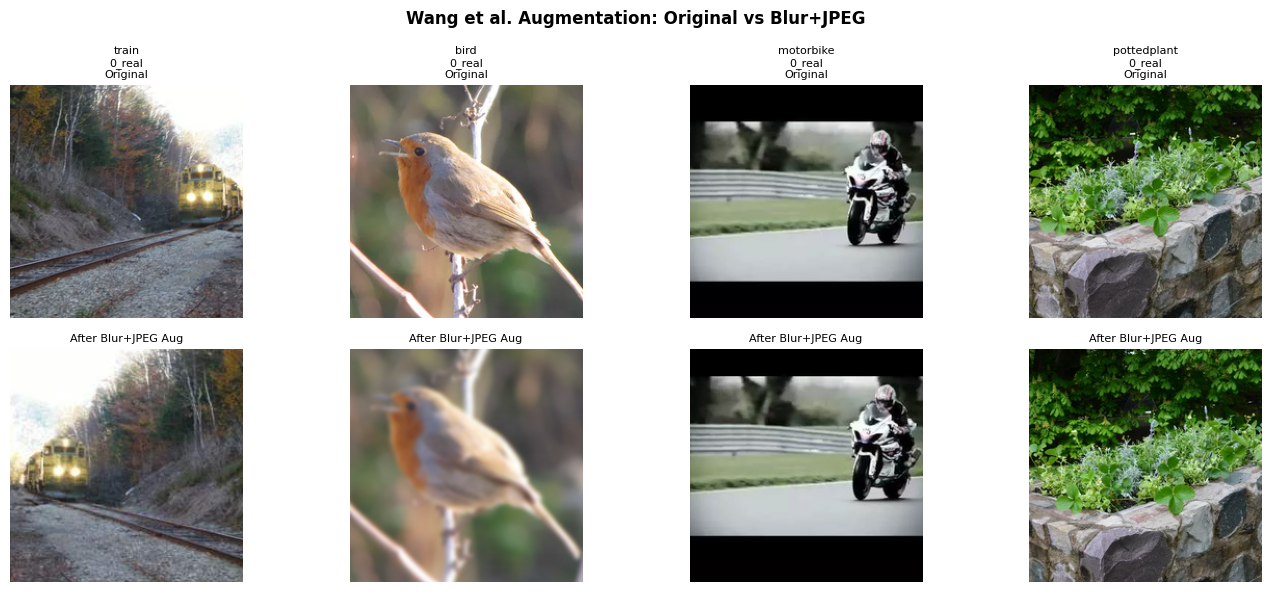

In [19]:
# ── Paper-specific augmentation transforms ────────────────────────────────────

class RandomGaussianBlur:
    """
    Wang et al. 2020: before cropping, with p probability,
    blur the image with sigma ~ Uniform[0, 3].
    """
    def __init__(self, p: float = 0.5):
        self.p = p

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() < self.p:
            sigma = random.uniform(0, 3)
            img   = img.filter(ImageFilter.GaussianBlur(radius=sigma))
        return img


class RandomJPEGCompression:
    """
    Wang et al. 2020: with p probability, JPEG-compress the image
    with quality ~ Uniform{30, 31, ..., 100}.
    Applied after blur (matching paper order).
    """
    def __init__(self, p: float = 0.5):
        self.p = p

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() < self.p:
            quality = random.randint(30, 100)
            buf     = BytesIO()
            img.save(buf, format='JPEG', quality=quality)
            buf.seek(0)
            img = Image.open(buf).convert('RGB')
        return img


# ── ImageNet normalisation stats ──────────────────────────────────────────────
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Training: blur + JPEG applied BEFORE crop (matches paper)
train_tf = transforms.Compose([
    transforms.Resize(256),                      # ensure image is large enough to crop
    RandomGaussianBlur(p=BLUR_PROB),             # paper aug #1: Gaussian blur
    RandomJPEGCompression(p=JPEG_PROB),          # paper aug #2: JPEG compression
    transforms.RandomCrop(IMG_SIZE),             # paper: random crop to 224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Evaluation: center crop only, NO blur/JPEG, NO resize (paper matches train preprocessing)
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),             # paper: center crop at test time
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


# ── Dataset class ─────────────────────────────────────────────────────────────
class RealFakeDataset(Dataset):
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root: Path, split: str, transform=None):
        self.root      = root / split
        self.transform = transform
        self.samples   = []
        self._build_index()

    def _build_index(self):
        for cls in CLASSES:
            for lbl_dir, lbl_id in LABEL_MAP.items():
                folder = self.root / cls / lbl_dir
                if not folder.exists():
                    continue
                for p in folder.iterdir():
                    if p.suffix.lower() in self.IMG_EXTS:
                        self.samples.append((p, lbl_id, cls))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, cls = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, cls


# ── Build datasets ────────────────────────────────────────────────────────────
train_ds = RealFakeDataset(DATASET_ROOT, 'train', train_tf)
val_ds   = RealFakeDataset(DATASET_ROOT, 'val',   eval_tf)
test_ds  = RealFakeDataset(DATASET_ROOT, 'test',  eval_tf)

num_workers = 2 if DEVICE.type == 'cuda' else 0
pin_memory  = DEVICE.type == 'cuda'

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')


# ── Sanity check: visualise one batch with/without augmentation ───────────────
def show_aug_comparison(dataset_root, n=4):
    """Show original vs augmented version of the same images."""
    no_aug_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ])
    fig, axes = plt.subplots(2, n, figsize=(14, 6))
    img_paths = []
    for cls in random.sample(CLASSES, n):
        for lbl_dir in LABEL_MAP:
            folder = dataset_root / 'train' / cls / lbl_dir
            files  = list(folder.glob('*.*')) if folder.exists() else []
            if files:
                img_paths.append((random.choice(files), cls, lbl_dir))
                break
    for i, (path, cls, lbl) in enumerate(img_paths[:n]):
        raw = Image.open(path).convert('RGB')
        axes[0, i].imshow(no_aug_tf(raw).permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'{cls}\n{lbl}\nOriginal', fontsize=8)
        axes[0, i].axis('off')
        aug = train_tf(raw)
        aug_np = aug.permute(1, 2, 0).numpy()
        aug_np = (aug_np * std + mean)  # denorm
        axes[1, i].imshow(aug_np.clip(0, 1))
        axes[1, i].set_title('After Blur+JPEG Aug', fontsize=8)
        axes[1, i].axis('off')
    fig.suptitle('Wang et al. Augmentation: Original vs Blur+JPEG',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_aug_comparison(DATASET_ROOT)

## Cell 5 — Model: ResNet-50 (Wang et al. 2020)

In [20]:
def build_model(num_classes: int = 2) -> nn.Module:
    """
    Wang et al. 2020 use ResNet-50 pretrained on ImageNet,
    with only the final FC layer replaced for binary classification.
    This is intentionally minimal — the paper's strength comes from
    the augmentation strategy, not architectural complexity.
    """
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    # Replace final classification layer — paper keeps this simple
    in_features = model.fc.in_features   # 2048 for ResNet-50
    model.fc    = nn.Linear(in_features, num_classes)

    return model


model = build_model(num_classes=2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model         : {MODEL_NAME}')
print(f'Total params  : {total_params:,}')
print(f'Trainable     : {train_params:,}')
print(f'FC input dim  : 2048 → 2')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 


Model         : ResNet50-Wang2020
Total params  : 23,512,130
Trainable     : 23,512,130
FC input dim  : 2048 → 2


## Cell 6 — Training

In [21]:
# ── Loss & optimiser (paper: Adam, lr=1e-4, standard CE — no label smoothing) ─
criterion = nn.CrossEntropyLoss()    # standard CE — paper does not use label smoothing
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


def run_epoch(loader, model, criterion, optimizer=None, phase='train'):
    """
    Single epoch forward (+ optional backward) pass.
    Returns: avg_loss, accuracy, y_true, y_pred, y_proba (prob of Fake class)
    """
    training = (phase == 'train')
    model.train() if training else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_true, all_pred, all_proba = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels, _ in tqdm(loader, desc=phase, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            proba  = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            preds  = logits.argmax(dim=1).detach().cpu().numpy()
            lbls   = labels.cpu().numpy()

            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == lbls).sum()
            total      += imgs.size(0)

            all_true.extend(lbls.tolist())
            all_pred.extend(preds.tolist())
            all_proba.extend(proba.tolist())

    return (total_loss / total), (correct / total), all_true, all_pred, all_proba


# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'val_ap':     []}
best_val_ap, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, *_          = run_epoch(train_loader, model, criterion, optimizer, 'train')
    vl_loss, vl_acc, vt, vp, vpr = run_epoch(val_loader, model, criterion, phase='val')
    scheduler.step()

    vl_ap = average_precision_score(vt, vpr)   # AP is the paper's main metric

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_ap'].append(vl_ap)

    # Save best checkpoint based on AP (not accuracy, following the paper)
    if vl_ap > best_val_ap:
        best_val_ap = vl_ap
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch [{epoch:02d}/{EPOCHS}]  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  AP: {vl_ap:.4f}')

# Restore best checkpoint
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
print(f'\nBest validation AP: {best_val_ap:.4f}')

train:   0%|          | 0/1750 [00:00<?, ?it/s]

val:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [01/15]  Train Loss: 0.2533  Acc: 0.8870  |  Val Loss: 0.0440  Acc: 0.9860  AP: 0.9992


train:   0%|          | 0/1750 [00:00<?, ?it/s]

val:   0%|          | 0/375 [00:00<?, ?it/s]

...

val:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [14/15]  Train Loss: 0.0189  Acc: 0.9926  |  Val Loss: 0.0045  Acc: 0.9982  AP: 1.0000


train:   0%|          | 0/1750 [00:00<?, ?it/s]

val:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [15/15]  Train Loss: 0.0159  Acc: 0.9941  |  Val Loss: 0.0033  Acc: 0.9987  AP: 1.0000

Best validation AP: 1.0000


## Cell 7 — Training Curves

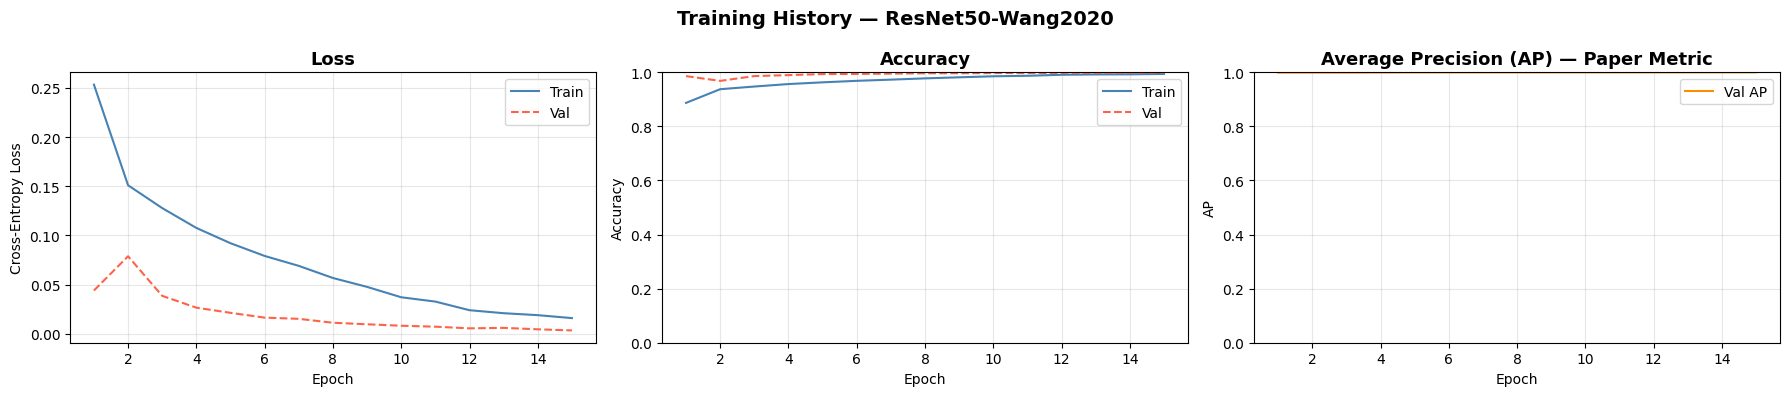

In [22]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato', linestyle='--')
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Average Precision (paper's primary metric)
axes[2].plot(epochs_range, history['val_ap'], label='Val AP', color='darkorange')
axes[2].set_title('Average Precision (AP) — Paper Metric', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AP')
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Training History — {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 8 — Evaluation on Test Set

In [23]:
_, test_acc, y_true, y_pred, y_proba = run_epoch(
    test_loader, model, criterion, phase='test'
)

# ── Primary metric: Average Precision (AP) — same as the paper ───────────────
ap_score  = average_precision_score(y_true, y_proba)
f1        = f1_score(y_true, y_pred, average='binary')
auc       = roc_auc_score(y_true, y_proba)

print('=' * 55)
print(f'  Average Precision (AP) [paper metric] : {ap_score:.4f}')
print(f'  Test Accuracy                         : {test_acc:.4f}')
print(f'  F1-Score                              : {f1:.4f}')
print(f'  ROC-AUC                               : {auc:.4f}')
print('=' * 55)
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

test:   0%|          | 0/375 [00:00<?, ?it/s]

  Average Precision (AP) [paper metric] : 1.0000
  Test Accuracy                         : 0.9988
  F1-Score                              : 0.9988
  ROC-AUC                               : 1.0000

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      6025
        Fake       1.00      1.00      1.00      5975

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



## Cell 9 — Confusion Matrix

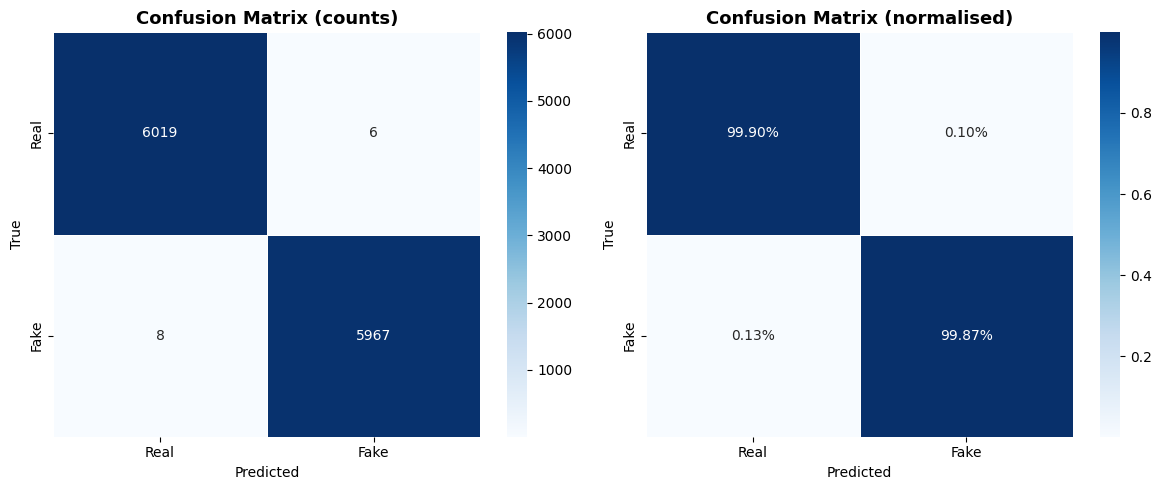

In [24]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.show()

## Cell 10 — ROC Curve & Precision-Recall Curve

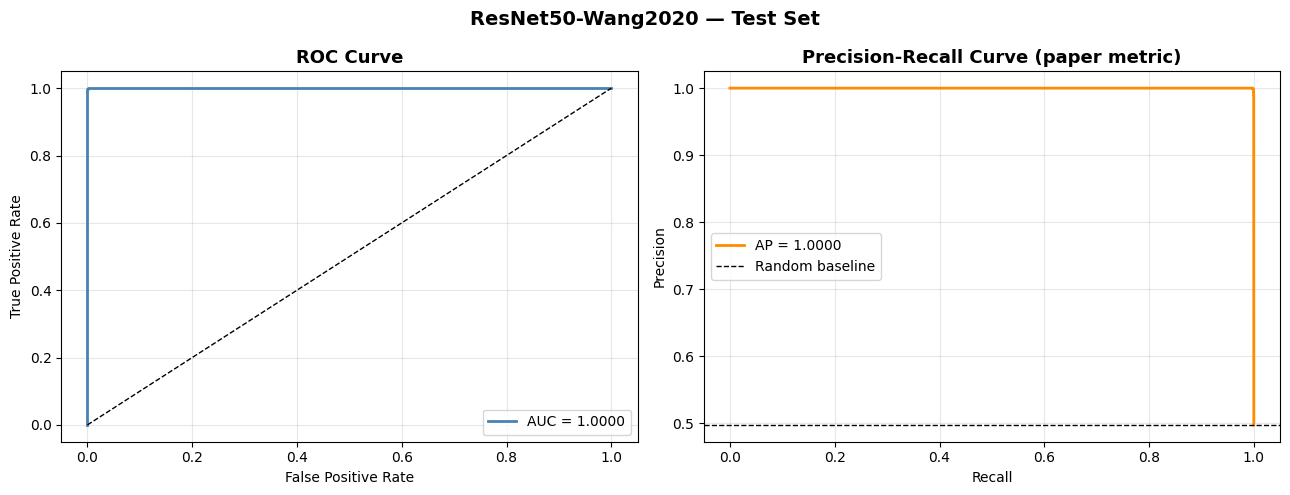

In [25]:
from sklearn.metrics import precision_recall_curve

fpr, tpr, _   = roc_curve(y_true, y_proba)
prec, rec, _  = precision_recall_curve(y_true, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right'); ax1.grid(alpha=0.3)

# Precision-Recall (AP is the area under this curve)
ax2.plot(rec, prec, color='darkorange', lw=2, label=f'AP = {ap_score:.4f}')
ax2.axhline(sum(y_true) / len(y_true), color='k', linestyle='--', lw=1,
            label='Random baseline')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (paper metric)', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 11 — Per-Class AP & Accuracy

Per-class eval:   0%|          | 0/375 [00:00<?, ?it/s]

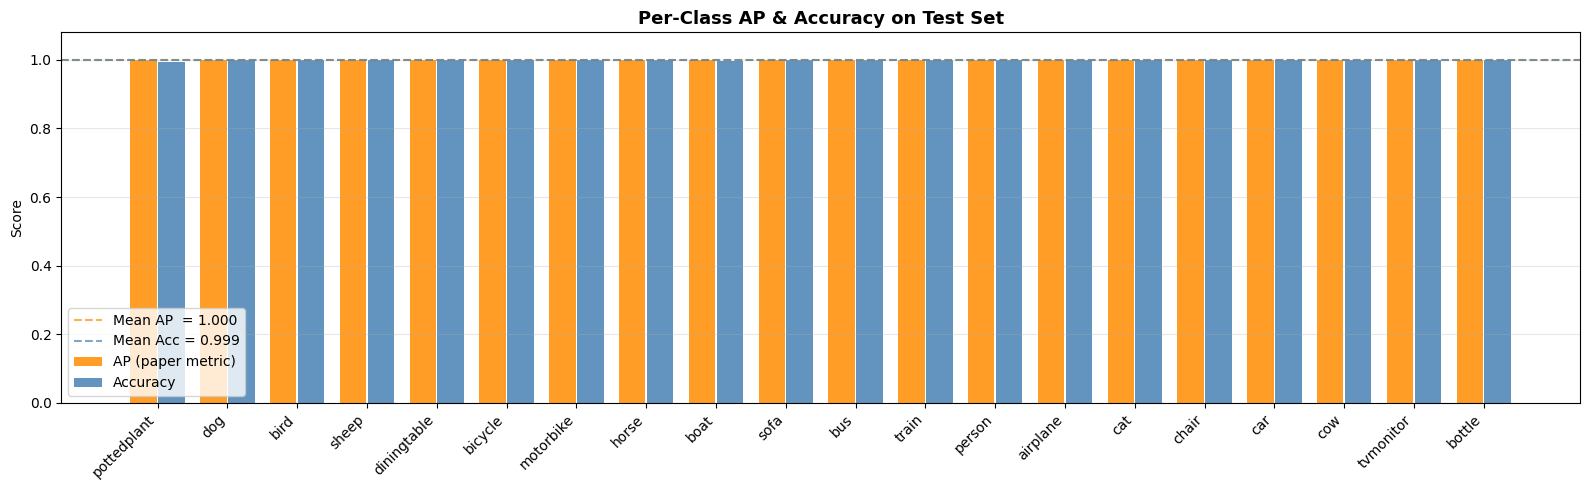


mAP (mean across all classes): 1.0000


In [26]:
model.eval()
class_results = defaultdict(lambda: {'y_true': [], 'y_pred': [], 'y_proba': []})

with torch.no_grad():
    for imgs, labels, cls_names in tqdm(test_loader, desc='Per-class eval'):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        labels = labels.numpy()
        for cls, lbl, pred, prob in zip(cls_names, labels, preds, proba):
            class_results[cls]['y_true'].append(lbl)
            class_results[cls]['y_pred'].append(pred)
            class_results[cls]['y_proba'].append(prob)

class_ap  = {}
class_acc = {}
for cls, res in class_results.items():
    yt, yp, ypr = res['y_true'], res['y_pred'], res['y_proba']
    # AP requires both classes to be present
    if len(set(yt)) > 1:
        class_ap[cls]  = average_precision_score(yt, ypr)
    else:
        class_ap[cls]  = float('nan')
    class_acc[cls] = accuracy_score(yt, yp)

# Sort by AP
sorted_cls = sorted(class_ap, key=lambda c: class_ap[c] if not np.isnan(class_ap[c]) else -1)
ap_vals    = [class_ap[c]  for c in sorted_cls]
acc_vals   = [class_acc[c] for c in sorted_cls]

x = np.arange(len(sorted_cls))
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - 0.2, ap_vals,  0.38, label='AP (paper metric)', color='darkorange', alpha=0.85)
ax.bar(x + 0.2, acc_vals, 0.38, label='Accuracy',          color='steelblue',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha='right')
ax.set_ylim(0, 1.08)
valid_ap = [v for v in ap_vals if not np.isnan(v)]
ax.axhline(np.mean(valid_ap),  color='darkorange', linestyle='--', alpha=0.7,
           label=f'Mean AP  = {np.mean(valid_ap):.3f}')
ax.axhline(np.mean(acc_vals), color='steelblue',   linestyle='--', alpha=0.7,
           label=f'Mean Acc = {np.mean(acc_vals):.3f}')
ax.set_title('Per-Class AP & Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nmAP (mean across all classes): {np.nanmean(list(class_ap.values())):.4f}')

## Cell 12 — Qualitative Results: Success & Failure Cases

/tmp/ipykernel_57/1042009030.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


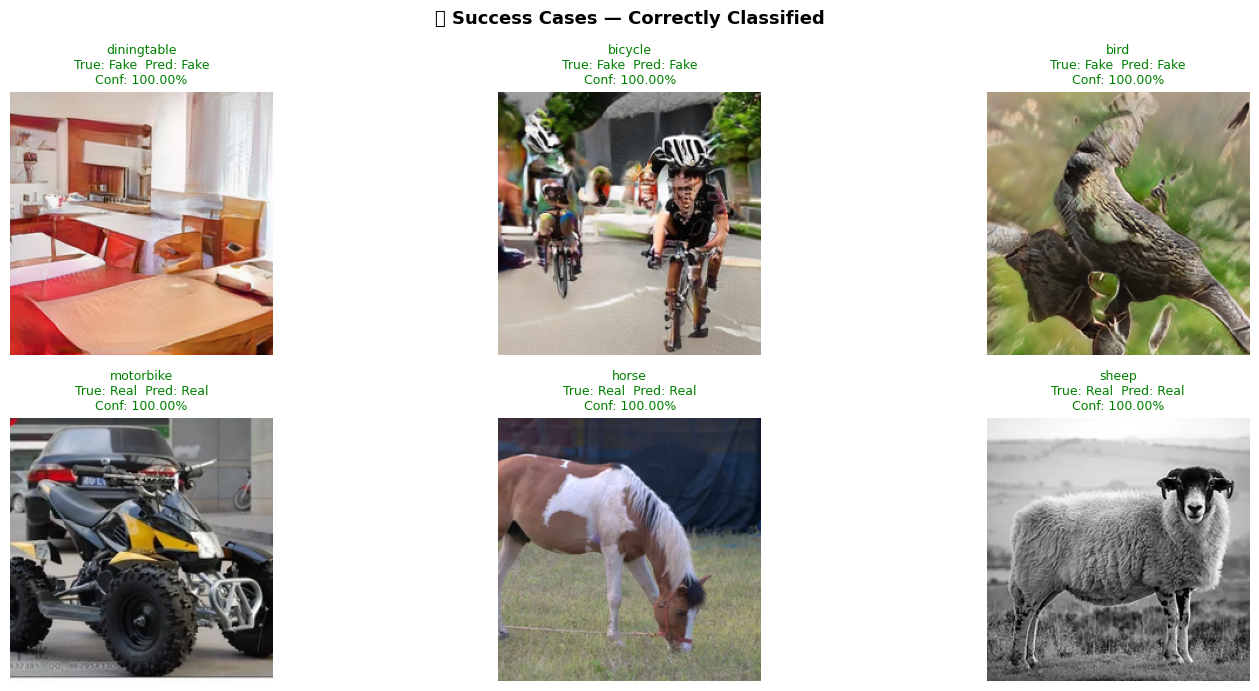

/tmp/ipykernel_57/1042009030.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


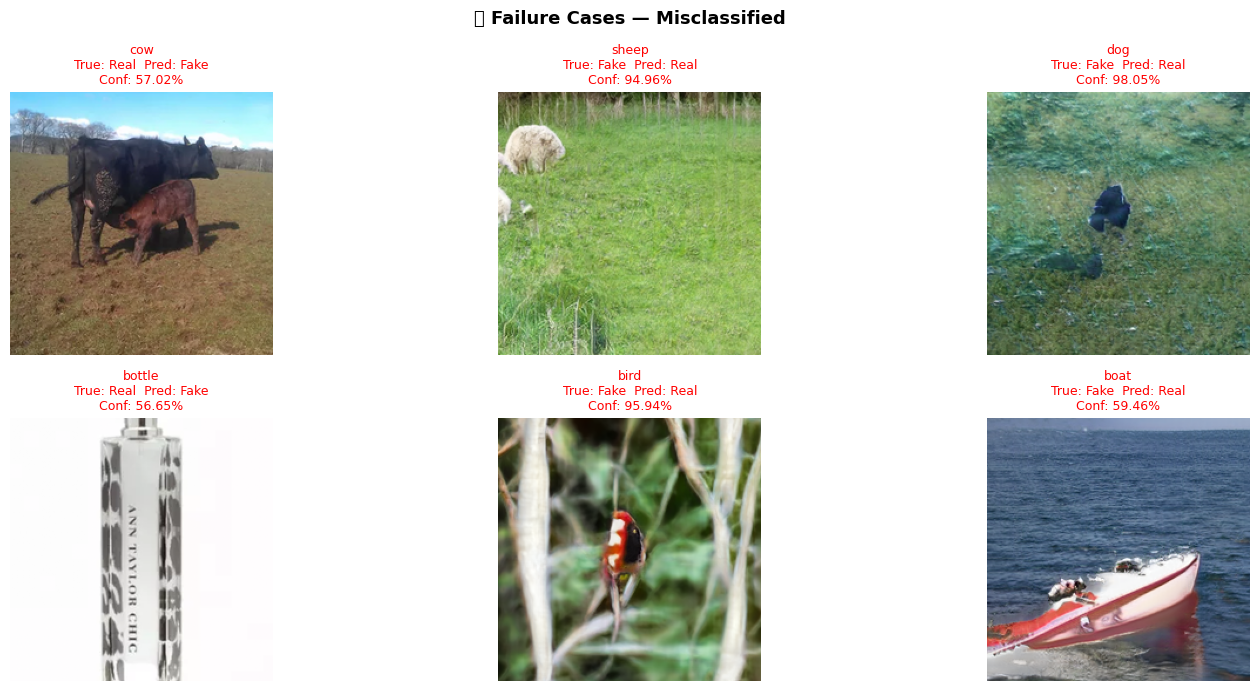

In [27]:
def denorm(tensor):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


def collect_cases(loader, model, n_each=6):
    successes, failures = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels, cls_names in loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            proba  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1).cpu()
            for i in range(len(imgs)):
                info = {
                    'img'       : imgs[i].cpu(),
                    'true_lbl'  : labels[i].item(),
                    'pred_lbl'  : preds[i].item(),
                    'conf'      : proba[i, preds[i]].item(),
                    'class_name': cls_names[i]
                }
                if preds[i] == labels[i] and len(successes) < n_each:
                    successes.append(info)
                elif preds[i] != labels[i] and len(failures) < n_each:
                    failures.append(info)
            if len(successes) >= n_each and len(failures) >= n_each:
                break
    return successes, failures


def plot_cases(cases, title):
    n   = len(cases)
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 7))
    axes = axes.flatten()
    for ax, info in zip(axes, cases):
        ax.imshow(denorm(info['img']))
        correct = info['pred_lbl'] == info['true_lbl']
        color   = 'green' if correct else 'red'
        ax.set_title(
            f"{info['class_name']}\n"
            f"True: {LABEL_NAME[info['true_lbl']]}  "
            f"Pred: {LABEL_NAME[info['pred_lbl']]}\n"
            f"Conf: {info['conf']:.2%}",
            fontsize=9, color=color
        )
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


successes, failures = collect_cases(test_loader, model, n_each=6)
plot_cases(successes, '✅ Success Cases — Correctly Classified')
plot_cases(failures,  '❌ Failure Cases — Misclassified')

## Cell 13 — Robustness Analysis (Wang et al. Section 4.2)
The paper specifically studies how well the model holds up when test images are blurred or JPEG-compressed after training. We replicate this experiment.

test:   0%|          | 0/375 [00:00<?, ?it/s]

Blur σ=0: AP=1.0000


test:   0%|          | 0/375 [00:00<?, ?it/s]

Blur σ=1: AP=1.0000


test:   0%|          | 0/375 [00:00<?, ?it/s]

...

JPEG quality=100: AP=1.0000


test:   0%|          | 0/375 [00:00<?, ?it/s]

JPEG quality=65: AP=0.9998


test:   0%|          | 0/375 [00:00<?, ?it/s]

JPEG quality=30: AP=0.9975


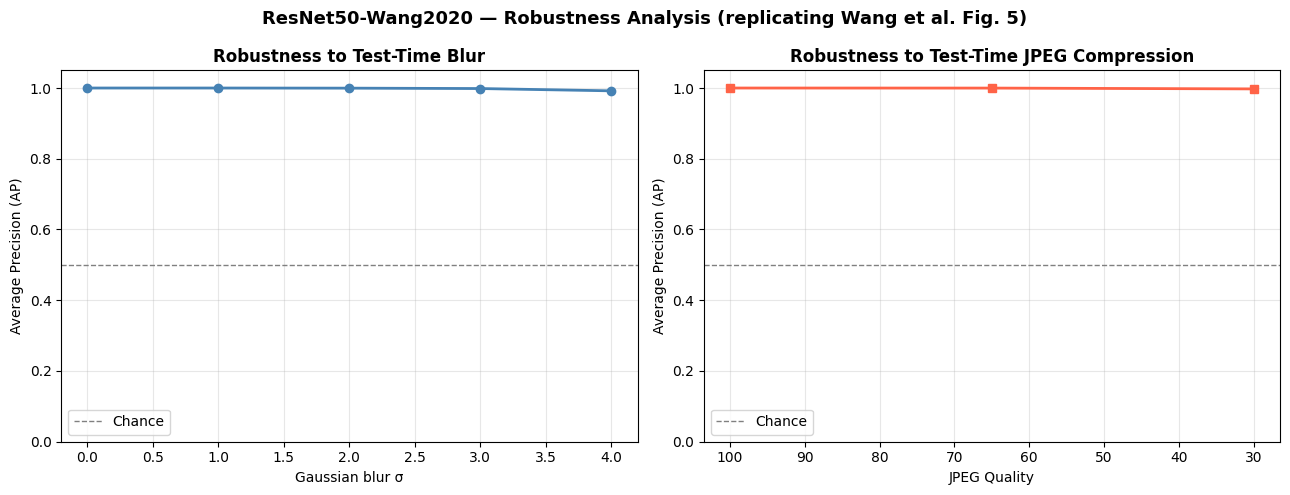

In [28]:
def build_perturbed_loader(perturbation: str, strength):
    """
    Build a test loader where images are post-processed with
    a given perturbation at test time — replicates paper Fig. 5.
    perturbation: 'blur' | 'jpeg'
    strength    : sigma (blur) | quality int (jpeg)
    """
    if perturbation == 'blur':
        extra = transforms.Lambda(
            lambda img: img.filter(ImageFilter.GaussianBlur(radius=strength))
        )
    else:  # jpeg
        def jpeg_fn(img):
            buf = BytesIO()
            img.save(buf, format='JPEG', quality=strength)
            buf.seek(0)
            return Image.open(buf).convert('RGB')
        extra = transforms.Lambda(jpeg_fn)

    perturbed_tf = transforms.Compose([
        transforms.Resize(256),
        extra,                           # apply perturbation before crop
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    ds = RealFakeDataset(DATASET_ROOT, 'test', perturbed_tf)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=num_workers, pin_memory=pin_memory)


# ── Blur robustness ───────────────────────────────────────────────────────────
blur_sigmas = [0, 1, 2, 3, 4]
blur_aps    = []
for sigma in blur_sigmas:
    loader = build_perturbed_loader('blur', sigma)
    _, _, yt, _, ypr = run_epoch(loader, model, criterion, phase='test')
    blur_aps.append(average_precision_score(yt, ypr))
    print(f'Blur σ={sigma}: AP={blur_aps[-1]:.4f}')

# ── JPEG robustness ───────────────────────────────────────────────────────────
jpeg_qualities = [100, 65, 30]
jpeg_aps       = []
for q in jpeg_qualities:
    loader = build_perturbed_loader('jpeg', q)
    _, _, yt, _, ypr = run_epoch(loader, model, criterion, phase='test')
    jpeg_aps.append(average_precision_score(yt, ypr))
    print(f'JPEG quality={q}: AP={jpeg_aps[-1]:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(blur_sigmas, blur_aps, marker='o', color='steelblue', linewidth=2)
ax1.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance')
ax1.set_xlabel('Gaussian blur σ')
ax1.set_ylabel('Average Precision (AP)')
ax1.set_title('Robustness to Test-Time Blur', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(jpeg_qualities, jpeg_aps, marker='s', color='tomato', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance')
ax2.set_xlabel('JPEG Quality')
ax2.set_ylabel('Average Precision (AP)')
ax2.set_title('Robustness to Test-Time JPEG Compression', fontsize=12, fontweight='bold')
ax2.invert_xaxis()   # lower quality = more compression = harder
ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — Robustness Analysis (replicating Wang et al. Fig. 5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 14 — Baseline Comparison

                               AP     Acc     AUC
Model                                            
Random Classifier          0.5005  0.4937  0.4995
Majority-Class Classifier  0.4979  0.4979  0.5000
ResNet50-Wang2020 (ours)   1.0000  0.9988  1.0000


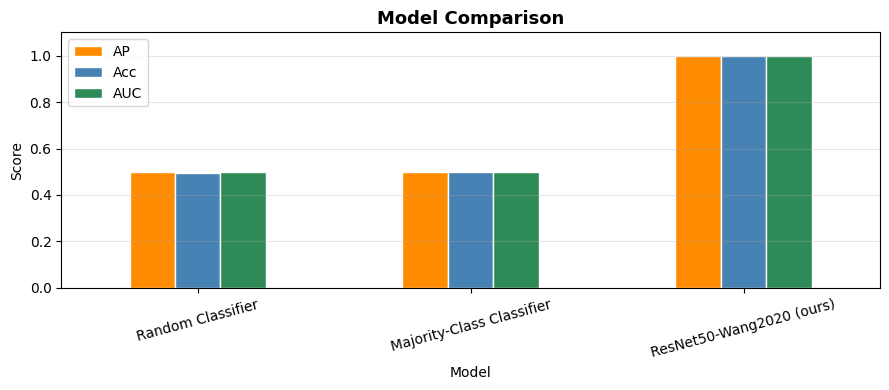

In [29]:
random_proba   = np.random.uniform(0, 1, size=len(y_true))
majority_proba = np.full(len(y_true), float(np.mean(y_true)))

results = pd.DataFrame([
    {'Model': 'Random Classifier',
     'AP'   : average_precision_score(y_true, random_proba),
     'Acc'  : accuracy_score(y_true, (random_proba > 0.5).astype(int)),
     'AUC'  : roc_auc_score(y_true, random_proba)},

    {'Model': 'Majority-Class Classifier',
     'AP'   : average_precision_score(y_true, majority_proba),
     'Acc'  : accuracy_score(y_true, np.ones(len(y_true), dtype=int)),
     'AUC'  : 0.5},

    {'Model': f'{MODEL_NAME} (ours)',
     'AP'   : ap_score,
     'Acc'  : test_acc,
     'AUC'  : auc},
]).set_index('Model')

print(results.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
results.plot(kind='bar', ax=ax,
             color=['darkorange', 'steelblue', 'seagreen'],
             edgecolor='white', rot=15)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 15 — Grad-CAM Visualisation

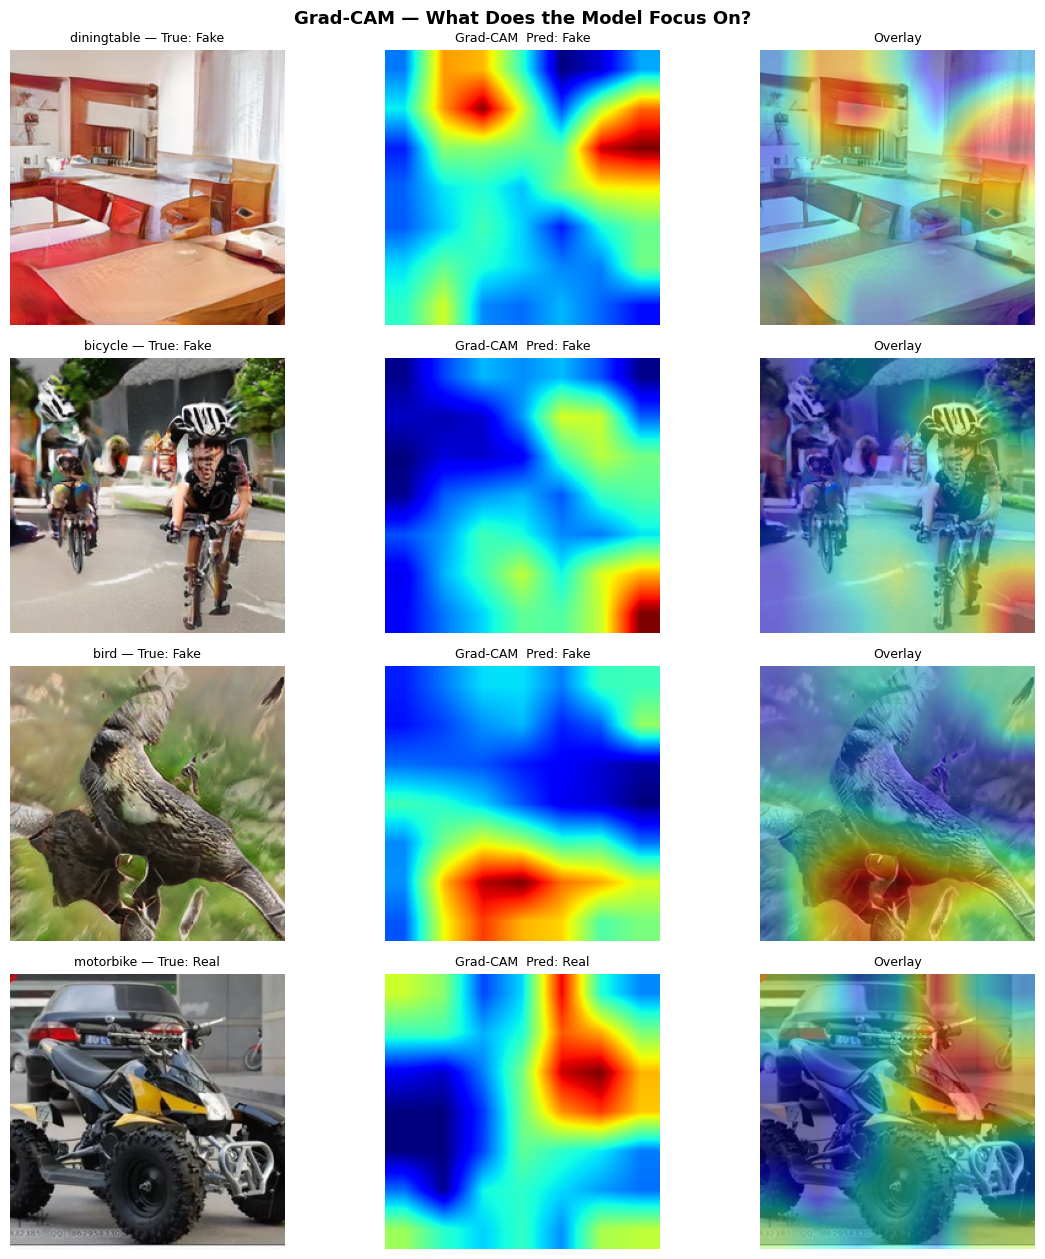

In [30]:
import torch.nn.functional as F

class GradCAM:
    """Minimal Grad-CAM for ResNet-50."""
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(
            lambda _, __, out: setattr(self, 'activations', out.detach())
        )
        target_layer.register_full_backward_hook(
            lambda _, __, grad_out: setattr(self, 'gradients', grad_out[0].detach())
        )

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        logits = self.model(img_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam, class_idx


# ResNet-50: target the last residual block's conv output
grad_cam = GradCAM(model, model.layer4[-1])

sample_imgs, sample_labels, sample_cls = next(iter(test_loader))
N_SHOW = 4

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, N_SHOW * 3.2))
for i in range(N_SHOW):
    cam, pred_idx = grad_cam.generate(sample_imgs[i])
    img_np   = denorm(sample_imgs[i])
    heatmap  = plt.cm.jet(cam)[:, :, :3]
    overlay  = (0.55 * img_np + 0.45 * heatmap).clip(0, 1)
    lbl      = sample_labels[i].item()

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(
        f"{sample_cls[i]} — True: {LABEL_NAME[lbl]}", fontsize=9
    )
    axes[i, 1].imshow(cam, cmap='jet')
    axes[i, 1].set_title(
        f"Grad-CAM  Pred: {LABEL_NAME[pred_idx]}", fontsize=9
    )
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay', fontsize=9)
    for ax in axes[i]: ax.axis('off')

fig.suptitle('Grad-CAM — What Does the Model Focus On?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 16 — Save Checkpoint

In [31]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'test_ap'         : ap_score,
    'test_accuracy'   : test_acc,
    'best_val_ap'     : best_val_ap,
    'history'         : history,
    'config': {
        'model'       : MODEL_NAME,
        'img_size'    : IMG_SIZE,
        'num_classes' : 2,
        'epochs'      : EPOCHS,
        'lr'          : LR,
        'blur_prob'   : BLUR_PROB,
        'jpeg_prob'   : JPEG_PROB,
    }
}
save_path = '/kaggle/working/resnet50_wang2020.pth'
torch.save(checkpoint, save_path)
print(f'Checkpoint saved → {save_path}')
print(f'Test AP  : {ap_score:.4f}')
print(f'Test Acc : {test_acc:.4f}')

Checkpoint saved → /kaggle/working/resnet50_wang2020.pth
Test AP  : 1.0000
Test Acc : 0.9988
